In [3]:
# ============================================================
# 01 - Exploratory Data Analysis (EDA)
# Project : E-Commerce Customer Churn Analysis
# Author  : Alexander Lau Poung Jie
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("output", exist_ok=True)

# 讀取 Excel 檔（注意：xlsx 用 read_excel，不是 read_csv）
df = pd.read_excel("data/E Commerce Dataset.xlsx", sheet_name="E Comm")

print("=== 資料基本資訊 ===")
print(f"總列數（客戶數）: {df.shape[0]}")
print(f"總欄數（變數數）: {df.shape[1]}")
print(f"\n欄位名稱與型別：")
print(df.dtypes)
print(f"\n前5筆資料：")
df.head()

=== 資料基本資訊 ===
總列數（客戶數）: 5630
總欄數（變數數）: 20

欄位名稱與型別：
CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

前5筆資料：


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [4]:
# ============================================================
# Cell 2 - 缺失值分析
# ============================================================

print("=== 缺失值分析 ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "缺失數量": missing,
    "缺失比例(%)": missing_pct
}).query("缺失數量 > 0").sort_values("缺失比例(%)", ascending=False)

print(missing_df)
print(f"\n總缺失值: {df.isnull().sum().sum()}")
print(f"\n=== 目標變數分佈 ===")
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100
print(f"留存（0）: {churn_counts[0]} 人 ({churn_pct[0]:.1f}%)")
print(f"流失（1）: {churn_counts[1]} 人 ({churn_pct[1]:.1f}%)")

=== 缺失值分析 ===
                             缺失數量  缺失比例(%)
DaySinceLastOrder             307     5.45
OrderAmountHikeFromlastYear   265     4.71
Tenure                        264     4.69
OrderCount                    258     4.58
CouponUsed                    256     4.55
HourSpendOnApp                255     4.53
WarehouseToHome               251     4.46

總缺失值: 1856

=== 目標變數分佈 ===
留存（0）: 4682 人 (83.2%)
流失（1）: 948 人 (16.8%)


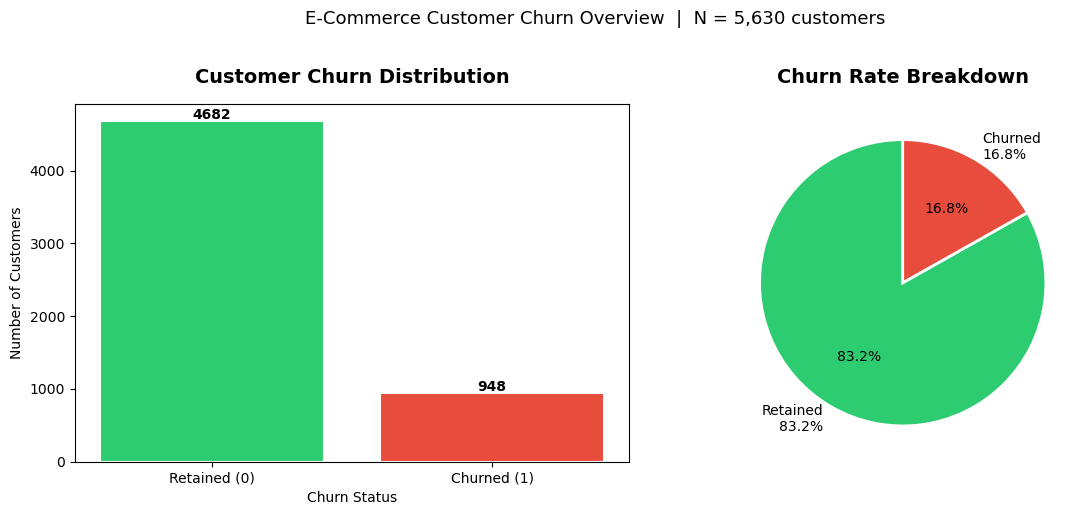

Saved: output/01_churn_distribution.png


In [7]:
# ============================================================
# Cell 3 - 視覺化：流失率分佈（英文版）
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#2ecc71", "#e74c3c"]

# 左圖：長條圖
axes[0].bar(["Retained (0)", "Churned (1)"],
            [churn_counts[0], churn_counts[1]],
            color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Customer Churn Distribution", fontsize=14,
                   fontweight="bold", pad=15)
axes[0].set_ylabel("Number of Customers")
axes[0].set_xlabel("Churn Status")
for i, v in enumerate([churn_counts[0], churn_counts[1]]):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# 右圖：圓餅圖
axes[1].pie(
    [churn_counts[0], churn_counts[1]],
    labels=["Retained\n83.2%", "Churned\n16.8%"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Churn Rate Breakdown", fontsize=14,
                   fontweight="bold", pad=15)

plt.suptitle("E-Commerce Customer Churn Overview  |  N = 5,630 customers",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("output/01_churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/01_churn_distribution.png")

In [8]:
print(f"資料載入狀態: {df.shape[0]} 列 x {df.shape[1]} 欄")
print(f"Churn 欄位: {df['Churn'].value_counts().to_dict()}")

資料載入狀態: 5630 列 x 20 欄
Churn 欄位: {0: 4682, 1: 948}


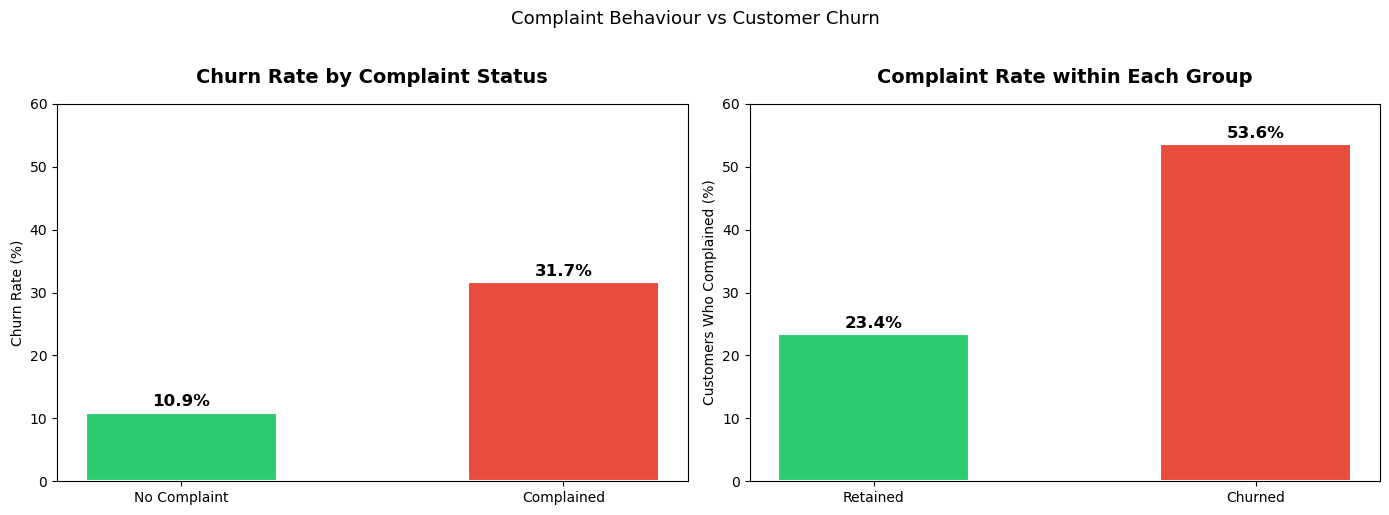

Saved: output/02_complaint_vs_churn.png


In [9]:
# ============================================================
# Cell 4 - 投訴 vs 流失
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左圖：有投訴 vs 沒投訴的流失率
complain_churn = df.groupby("Complain")["Churn"].mean() * 100

axes[0].bar(["No Complaint", "Complained"],
            complain_churn.values,
            color=["#2ecc71", "#e74c3c"],
            edgecolor="white", linewidth=1.5, width=0.5)
axes[0].set_title("Churn Rate by Complaint Status",
                   fontsize=14, fontweight="bold", pad=15)
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 60)
for i, v in enumerate(complain_churn.values):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center",
                  fontweight="bold", fontsize=12)

# 右圖：流失 vs 留存客戶中，投訴比例各是多少
complain_by_churn = df.groupby("Churn")["Complain"].mean() * 100
bars = axes[1].bar(["Retained", "Churned"],
                    complain_by_churn.values,
                    color=["#2ecc71", "#e74c3c"],
                    edgecolor="white", linewidth=1.5, width=0.5)
axes[1].set_title("Complaint Rate within Each Group",
                   fontsize=14, fontweight="bold", pad=15)
axes[1].set_ylabel("Customers Who Complained (%)")
axes[1].set_ylim(0, 60)
for i, v in enumerate(complain_by_churn.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center",
                  fontweight="bold", fontsize=12)

plt.suptitle("Complaint Behaviour vs Customer Churn",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("output/02_complaint_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/02_complaint_vs_churn.png")

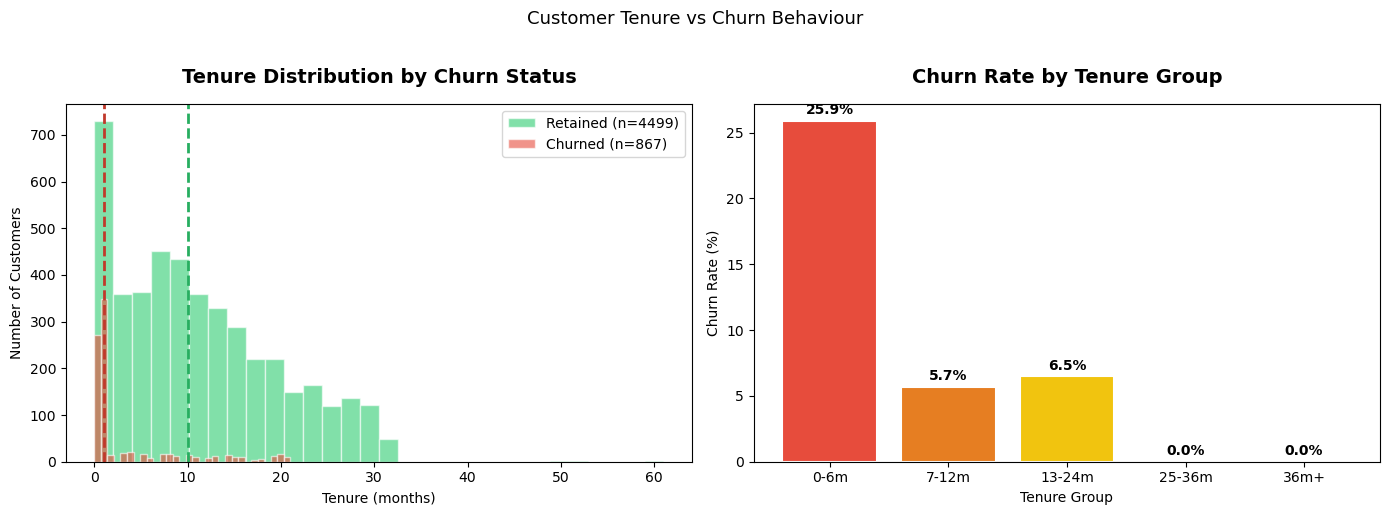

Saved: output/03_tenure_vs_churn.png


In [10]:
# ============================================================
# Cell 5 - Tenure（使用年資）vs 流失
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左圖：Tenure 分佈（流失 vs 留存）
retained = df[df["Churn"] == 0]["Tenure"].dropna()
churned  = df[df["Churn"] == 1]["Tenure"].dropna()

axes[0].hist(retained, bins=30, alpha=0.6, color="#2ecc71",
             label=f"Retained (n={len(retained)})", edgecolor="white")
axes[0].hist(churned, bins=30, alpha=0.6, color="#e74c3c",
             label=f"Churned (n={len(churned)})", edgecolor="white")
axes[0].set_title("Tenure Distribution by Churn Status",
                   fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Number of Customers")
axes[0].legend()
axes[0].axvline(retained.median(), color="#27ae60", linestyle="--",
                linewidth=2, label=f"Retained median: {retained.median()}")
axes[0].axvline(churned.median(), color="#c0392b", linestyle="--",
                linewidth=2)

# 右圖：按 Tenure 分組的流失率
df["TenureGroup"] = pd.cut(df["Tenure"],
                            bins=[0, 6, 12, 24, 36, 100],
                            labels=["0-6m", "7-12m", "13-24m",
                                    "25-36m", "36m+"])
tenure_churn = df.groupby("TenureGroup", observed=True)["Churn"].mean() * 100

axes[1].bar(tenure_churn.index, tenure_churn.values,
            color=["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"],
            edgecolor="white", linewidth=1.5)
axes[1].set_title("Churn Rate by Tenure Group",
                   fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("Tenure Group")
axes[1].set_ylabel("Churn Rate (%)")
for i, v in enumerate(tenure_churn.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Customer Tenure vs Churn Behaviour",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("output/03_tenure_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/03_tenure_vs_churn.png")

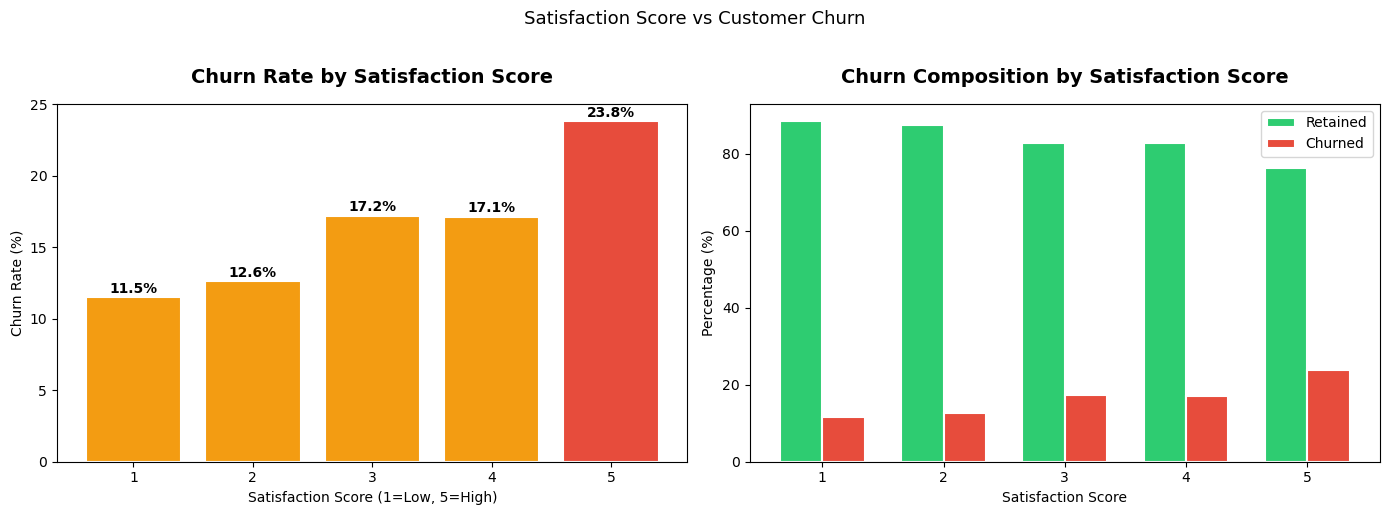

Saved: output/04_satisfaction_vs_churn.png


In [11]:
# ============================================================
# Cell 6 - 滿意度 vs 流失
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左圖：各滿意度分數的流失率
sat_churn = df.groupby("SatisfactionScore")["Churn"].mean() * 100
colors_sat = ["#e74c3c" if v > 20 else "#f39c12" 
              if v > 10 else "#2ecc71" for v in sat_churn.values]

axes[0].bar(sat_churn.index, sat_churn.values,
            color=colors_sat, edgecolor="white", linewidth=1.5)
axes[0].set_title("Churn Rate by Satisfaction Score",
                   fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("Satisfaction Score (1=Low, 5=High)")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_xticks([1, 2, 3, 4, 5])
for i, (score, v) in enumerate(sat_churn.items()):
    axes[0].text(score, v + 0.3, f"{v:.1f}%",
                  ha="center", fontweight="bold")

# 右圖：流失 vs 留存的滿意度分佈
sat_dist = df.groupby(["SatisfactionScore", "Churn"]).size().unstack()
sat_dist_pct = sat_dist.div(sat_dist.sum(axis=1), axis=0) * 100

sat_dist_pct.plot(kind="bar", ax=axes[1],
                   color=["#2ecc71", "#e74c3c"],
                   edgecolor="white", linewidth=1.5,
                   width=0.7)
axes[1].set_title("Churn Composition by Satisfaction Score",
                   fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("Satisfaction Score")
axes[1].set_ylabel("Percentage (%)")
axes[1].legend(["Retained", "Churned"], loc="upper right")
axes[1].set_xticklabels([1, 2, 3, 4, 5], rotation=0)

plt.suptitle("Satisfaction Score vs Customer Churn",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("output/04_satisfaction_vs_churn.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/04_satisfaction_vs_churn.png")

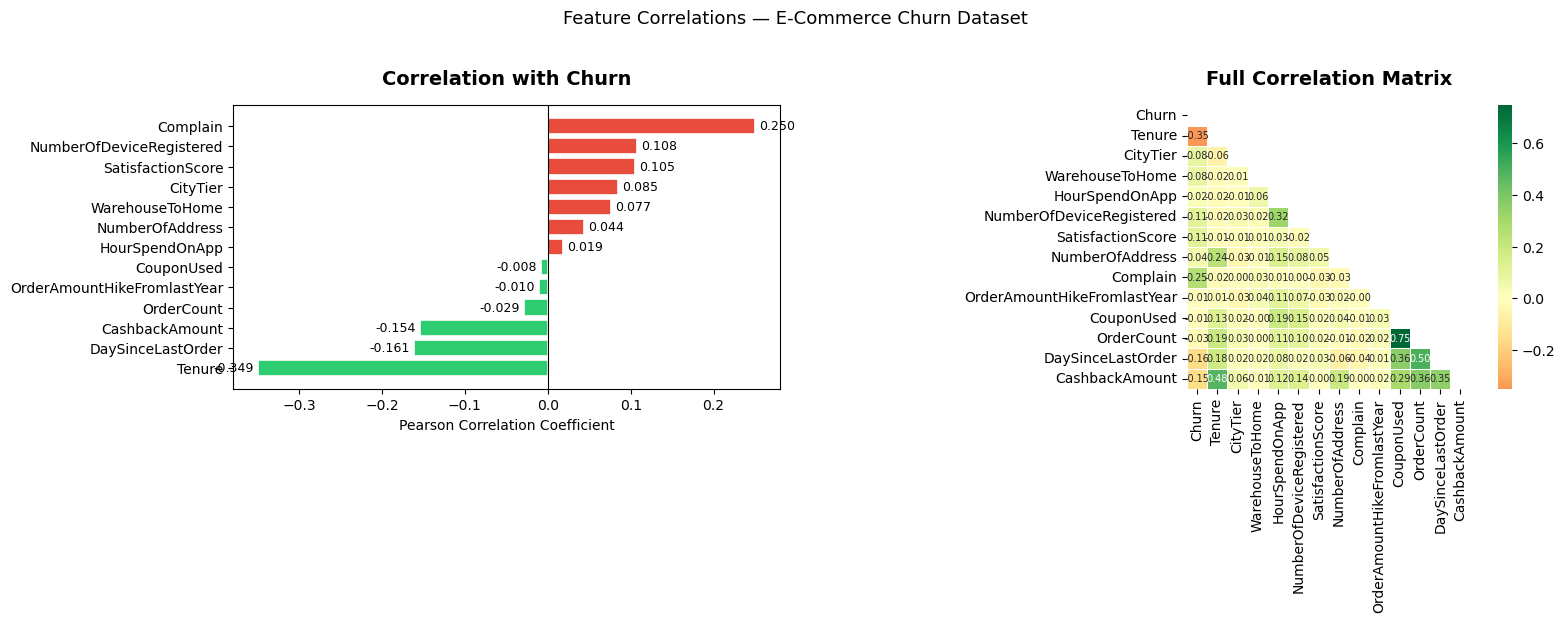

Saved: output/05_correlation_heatmap.png


In [12]:
# ============================================================
# Cell 7 - 相關係數熱力圖
# ============================================================

# 只選數字欄位
numeric_df = df.select_dtypes(include=[np.number]).drop(
    columns=["CustomerID", "TenureGroup"], errors="ignore"
)

corr_matrix = numeric_df.corr()

# 只取與 Churn 相關的欄位，排序
churn_corr = corr_matrix["Churn"].drop("Churn").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左圖：與 Churn 的相關係數條狀圖
colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in churn_corr.values]
axes[0].barh(churn_corr.index, churn_corr.values,
             color=colors, edgecolor="white", linewidth=1.2)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Correlation with Churn",
                   fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("Pearson Correlation Coefficient")
for i, v in enumerate(churn_corr.values):
    ha = "left" if v >= 0 else "right"
    offset = 0.005 if v >= 0 else -0.005
    axes[0].text(v + offset, i, f"{v:.3f}", va="center",
                  ha=ha, fontsize=9)

# 右圖：完整熱力圖
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            ax=axes[1],
            cmap="RdYlGn",
            center=0,
            annot=True,
            fmt=".2f",
            annot_kws={"size": 7},
            linewidths=0.5,
            square=True)
axes[1].set_title("Full Correlation Matrix",
                   fontsize=14, fontweight="bold", pad=15)

plt.suptitle("Feature Correlations — E-Commerce Churn Dataset",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("output/05_correlation_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/05_correlation_heatmap.png")